<a href="https://colab.research.google.com/github/MageroOduor/Predictive-Modelling-of-Flood-Risk/blob/main/Predictive_Modeling_of_Flood_Risk_Magero_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement**

Rapidly growing cities worldwide face increasing flood risks due to complex interactions between environmental factors (e.g., climate change, monsoon intensity) and urban development (e.g., urbanization, inadequate drainage systems). However, real-world flood data is often scarce or inconsistent, making accurate risk prediction a significant challenge. This project addresses the critical need for robust flood risk prediction by performing a case study using a synthetic, multi-domain environmental indicator dataset.

#**General Objective**

To develop and evaluate machine learning models that can effectively identify high-risk areas and influential factors, providing a framework that can inform disaster preparedness, urban planning, and resource allocation strategies, ultimately aiming to mitigate the socio-economic impacts of flooding, even when real-world data limitations exist.



#**Specific Objectives:**

1. Conduct comprehensive Exploratory Data Analysis (EDA) to understand feature distributions, identify correlations, and detect potential anomalies in the dataset;
2. Perform feature engineering and preprocessing (e.g., scaling) to optimize the data for machine learning models;
3. Build, evaluate, and interpret multiple machine learning models (Linear Regression, Random Forest, and XGBoost) to predict flood probability using RMSE, and identify the most influential predictors of flood risk; and
4. Deploy the best-performing model using Streamlit to develop an interactive interface for real-time flood probability prediction.


# **Bias and Fairness**

Bias in machine learning models, especially those used for critical predictions like flood risk, can lead to severe and inequitable outcomes. While this is a synthetic dataset, it's crucial to consider potential sources of bias and their implications for fairness if such a model were deployed in real-world scenarios.

**Potential Sources of Bias in the Dataset**
1.  **PopulationScore:** This feature likely represents population density or vulnerability. If the synthetic generation implicitly links lower `PopulationScore` (e.g., less dense or wealthier areas) to lower flood probability, or higher scores (e.g., denser, potentially poorer areas) to higher flood probability, it could perpetuate or amplify existing societal inequalities. In reality, vulnerable populations often live in high-risk areas with inadequate infrastructure.
2.  **Urbanization:** Urbanization is a complex process. If the dataset's `Urbanization` metric disproportionately penalizes certain types of urban development or implicitly favors others, the model could recommend policies that disadvantage specific communities or types of urban growth.
3.  **PoliticalFactors:** This feature is highly abstract and fraught with potential for bias. If `PoliticalFactors` are correlated with lower flood probability, it might imply that areas with certain political characteristics (which could be proxies for socioeconomic status, power, or governance effectiveness) receive preferential treatment in flood management or are inherently less at risk in the synthetic world. In a real-world context, such a feature could be a proxy for corruption, political will, or historical underinvestment, leading to unfair risk assessments for marginalized communities.

**Implications of Synthetic Data on Observed Biases**

Being a synthetic dataset, any observed biases are a direct result of the data generation process. This could be a strength, allowing for controlled study, or a limitation, as it might not fully capture the nuanced and often hidden biases present in real-world data. Real-world biases often stem from historical discrimination, data collection methods, and societal inequalities that are hard to replicate synthetically. Therefore, while this synthetic data can illustrate *types* of bias, the *magnitude* and *nature* of real-world bias could be significantly different.

**Ethical Implications and Fairness Issues**

If a biased model for flood risk prediction were deployed, it could have severe ethical and fairness implications:
*   **Resource Allocation:** A model biased against certain `PopulationScore` or `Urbanization` levels could lead to under-investment in flood preparedness or infrastructure in specific communities, increasing their vulnerability.
*   **Insurance and Lending:** Biased predictions could result in higher insurance premiums or denial of loans for property development in certain areas, exacerbating economic disparities.
*   **Disaster Preparedness:** Emergency response planning based on biased risk assessments could lead to inadequate early warning systems or evacuation routes for disproportionately affected communities.
*   **Environmental Justice:** Flood risk is often a matter of environmental justice, where marginalized groups are more exposed to hazards. A biased model could deepen these existing injustices.

**Conclusion on Bias Mitigation**

This analysis primarily focuses on predictive performance and interpretability. Comprehensive bias detection and mitigation strategies (e.g., re-sampling, re-weighting, adversarial debiasing, or fairness-aware algorithms) are not explicitly performed in this project. However, the initial EDA and feature importance analysis serve as critical first steps in identifying features that *could* contribute to bias. For real-world applications, a dedicated and thorough bias audit, involving domain experts and affected communities, would be an indispensable next step to ensure ethical and fair deployment of flood risk prediction models.

# **1.0** **Import Libraries**

In [1]:
import pandas as pd  # for data manipulation and analysis (e.g., handling tables, CSV files, DataFrames)

import numpy as np  # for numerical computations, arrays, and mathematical operations

import matplotlib.pyplot as plt  #f or creating basic plots and visualizations (graphs, charts)

import seaborn as sns  # Built on matplotlib, used for more advanced and visually appealing statistical plots

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
# train_test_split: Splits data into training and testing sets
# RandomizedSearchCV: Used for hyperparameter tuning by trying random combinations
# KFold: Used for cross-validation (splitting data into folds for better model evaluation)

from sklearn.preprocessing import StandardScaler  # to normalize/scale data so features have mean = 0 and standard deviation = 1

from sklearn.linear_model import LinearRegression  # A simple machine learning model for predicting continuous values

from sklearn.metrics import mean_squared_error, r2_score
# mean_squared_error: Measures average squared difference between predicted and actual values
# r2_score: Measures how well the model explains the variance in the data (accuracy score)

from sklearn.ensemble import RandomForestRegressor  # An ensemble model that uses multiple decision trees for better predictions

from xgboost import XGBRegressor  # A powerful gradient boosting model used for high-performance predictions

!pip install streamlit  # for building simple web apps for our model)

import streamlit as st  # to create interactive web apps and user interfaces for your machine learning model

import pickle  # to save and load trained models (serialization)

print("All necessary libraries imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.8 MB/s eta 0:00:00
All necessary libraries imported.


# **2.0 Load the Data**

In [2]:
from google.colab import drive
drive.mount('/content/drive') # Mount the drive
file1_path = '/content/drive/MyDrive/CapstoneProject/Flood Risk/Flooding_Risk_train.csv'# Navigate to Your File
file2_path = '/content/drive/MyDrive/CapstoneProject/Flood Risk/Flooding_Risk_test.csv'# Navigate to Your File

train_df = pd.read_csv(file1_path)
test_df= pd.read_csv(file2_path)

Mounted at /content/drive


# **3.0 Exploratory Data Analysis (EDA)**

The goal of this step was to:

1. Understand the distributions of each feature.
2. Explore relationships between features and the target variable (`flood_risk`).
3. Identify any correlations or patterns that could inform feature engineering.
4. Identify the most influential predictors
5. Detect potential outliers or anomalies.

We visualized both **numerical distributions** and **feature correlations**, and summarized key insights.


**Data Inspection**

In [3]:
# Viewing a sample of rows
display(train_df.sample(frac=0.01)) # Print 1% of the data randomly
display(test_df.sample(frac=0.01))

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
672732,672732,5,2,2,5,3,5,3,7,6,...,3,8,2,3,9,11,1,4,5,0.515
442082,442082,3,4,3,1,8,5,8,8,6,...,5,5,6,2,4,4,5,1,6,0.440
240481,240481,5,9,2,5,5,3,6,5,5,...,2,5,4,4,6,12,4,6,4,0.520
453619,453619,11,2,4,5,6,5,5,2,6,...,9,6,3,4,4,5,5,5,7,0.510
16885,16885,3,1,6,4,3,5,4,3,4,...,6,7,9,2,1,5,3,4,5,0.495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107683,1107683,6,3,4,4,4,6,3,5,5,...,4,4,8,7,2,1,5,6,6,0.425
429499,429499,5,11,3,4,3,8,4,5,5,...,4,3,4,6,6,8,2,2,5,0.510
353143,353143,4,5,9,2,4,3,5,4,5,...,4,7,5,3,5,4,4,3,3,0.510
369260,369260,7,8,7,3,7,5,6,6,6,...,6,5,7,4,3,4,6,1,3,0.550


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
616069,1734026,5,4,5,2,8,4,6,5,2,...,5,3,4,4,8,4,4,4,7,5
551675,1669632,2,3,6,6,2,3,5,9,6,...,5,2,5,8,5,4,5,2,6,5
368041,1485998,2,2,5,7,8,6,7,3,8,...,2,5,3,4,1,3,5,7,3,3
46530,1164487,3,7,3,11,5,3,9,6,2,...,5,5,2,8,4,6,4,2,3,6
96633,1214590,8,7,5,6,6,7,5,6,8,...,3,6,6,4,5,9,6,5,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55032,1172989,8,7,8,4,3,8,6,5,3,...,8,7,6,8,4,4,3,8,2,4
689058,1807015,8,2,8,4,6,5,9,3,4,...,4,5,2,5,4,1,3,5,6,5
110008,1227965,3,5,6,2,5,7,7,5,5,...,5,6,3,3,4,4,2,4,10,0
225768,1343725,4,3,6,3,6,2,4,2,3,...,3,6,8,7,3,9,4,3,9,5


**Dimensions/ Structure of the dataset**

In [4]:
#Structure of the dataset
display(train_df.info())
display(test_df.info())

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745305 entries, 0 to 745304
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   id                               745305 non-null  int64
 1   MonsoonIntensity                 745305 non-null  int64
 2   TopographyDrainage               745305 non-null  int64
 3   RiverManagement                  745305 non-null  int64
 4   Deforestation                    745305 non-null  int64
 5   Urbanization                     745305 non-null  int64
 6   ClimateChange                    745305 non-null  int64
 7   DamsQuality                      745305 non-null  int64
 8   Siltation                        745305 non-null  int64
 9   AgriculturalPractices            745305 non-null  int64
 10  Encroachments                    745305 non-null  int64
 11  IneffectiveDisasterPreparedness  745305 non-null  int64
 12  DrainageSystems               

None

Train shape: (1117957, 22)
Test shape: (745305, 21)


**Descriptive statistics**

In [5]:
# Drop target variable
features_only = train_df.drop(columns=["FloodProbability", "id"])

# Summary statistics for numerical variables
numerical_summary = features_only.describe().T
print(f"Summary Statistics for Numerical Variables:\n{numerical_summary.to_string()}") # Prints a formatted summary of numerical variables, including a title and full descriptive statistics. # The to_string() method ensures the entire DataFrame is displayed without truncation, and \n # is used to improve readability by separating the title from the output.

Summary Statistics for Numerical Variables:
                                     count      mean       std  min  25%  50%  75%   max
MonsoonIntensity                 1117957.0  4.921450  2.056387  0.0  3.0  5.0  6.0  16.0
TopographyDrainage               1117957.0  4.926671  2.093879  0.0  3.0  5.0  6.0  18.0
RiverManagement                  1117957.0  4.955322  2.072186  0.0  4.0  5.0  6.0  16.0
Deforestation                    1117957.0  4.942240  2.051689  0.0  4.0  5.0  6.0  17.0
Urbanization                     1117957.0  4.942517  2.083391  0.0  3.0  5.0  6.0  17.0
ClimateChange                    1117957.0  4.934093  2.057742  0.0  3.0  5.0  6.0  17.0
DamsQuality                      1117957.0  4.955878  2.083063  0.0  4.0  5.0  6.0  16.0
Siltation                        1117957.0  4.927791  2.065992  0.0  3.0  5.0  6.0  16.0
AgriculturalPractices            1117957.0  4.942619  2.068545  0.0  3.0  5.0  6.0  16.0
Encroachments                    1117957.0  4.949230  2.083324  0.

*   The dataset exhibited strong consistency in its statistical properties across all features. The mean and median values are both approximately 5, indicating that the data is well-centered and symmetrically distributed, with little to no skewness. This suggests that there was no need for transformations aimed at correcting skewness, such as logarithmic or power transformations.

*   The standard deviation was consistently around 2, reflecting a moderate level of spread. This indicates that the data is neither too tightly clustered nor excessively dispersed, making it suitable for most machine learning models without requiring major adjustments for variance. As such, standard scaling was sufficient for our algorithms.


*   Although the minimum values were 0 and the maximum values extended up to approximately 16–19, the quartile distribution showed that most data points lie between 3 and 6. This suggests that while extreme values exist, they are relatively few and do not dominate the dataset. Therefore, aggressive outlier removal may not be necessary. However, it was stil prudent to verify whether these extreme values are valid or artificially generated, especially given the uniformity across features.


*   The tight clustering of quartiles and the similarity in distributions across all variables further indicated that the dataset is highly uniform, which may point to a synthetic or engineered dataset. From a data preparation perspective, this reduced the need for extensive cleaning, as there were no signs of missing values, severe skewness, or inconsistent variability. However, it also suggested that feature engineering and interaction terms played a more important role in improving model performance than basic data cleaning.

*   Overall, the dataset appeared clean, balanced, and ready for modeling, requiring minimal preprocessing beyond standard scaling and validation of extreme values.







**Checking for missing values**

In [6]:
# Check for missing values
print("\nMissing values for train dataset:\n", train_df.isnull().sum())
print("\nMissing values for test dataset:\n", test_df.isnull().sum())


Missing values for train dataset:
 id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

Missing values for test dataset:
 id                                 0
MonsoonIntensity                   0
TopographyDrainage          

**Checking for Duplicates**

In [7]:
# Checking for Duplicates
train_df.duplicated().sum()
test_df.duplicated().sum()

np.int64(0)

**Feature Relationships with Flood Probability**


We explored how individual features relate to the target variable, `FloodProbability` by visualizing distributions for all numerical features in the train DataFrame, excluding the id and FloodProbability columns, to understand their individual distributions. We ensured the plots are well-organized using subplots. and created a correlation matrix  by displaying it as a heatmap to identify relationships between variables.

Understanding these relationships helped us to:
- Identify the most influential predictors
- Detect linear or non-linear trends
- Guide feature engineering decisions

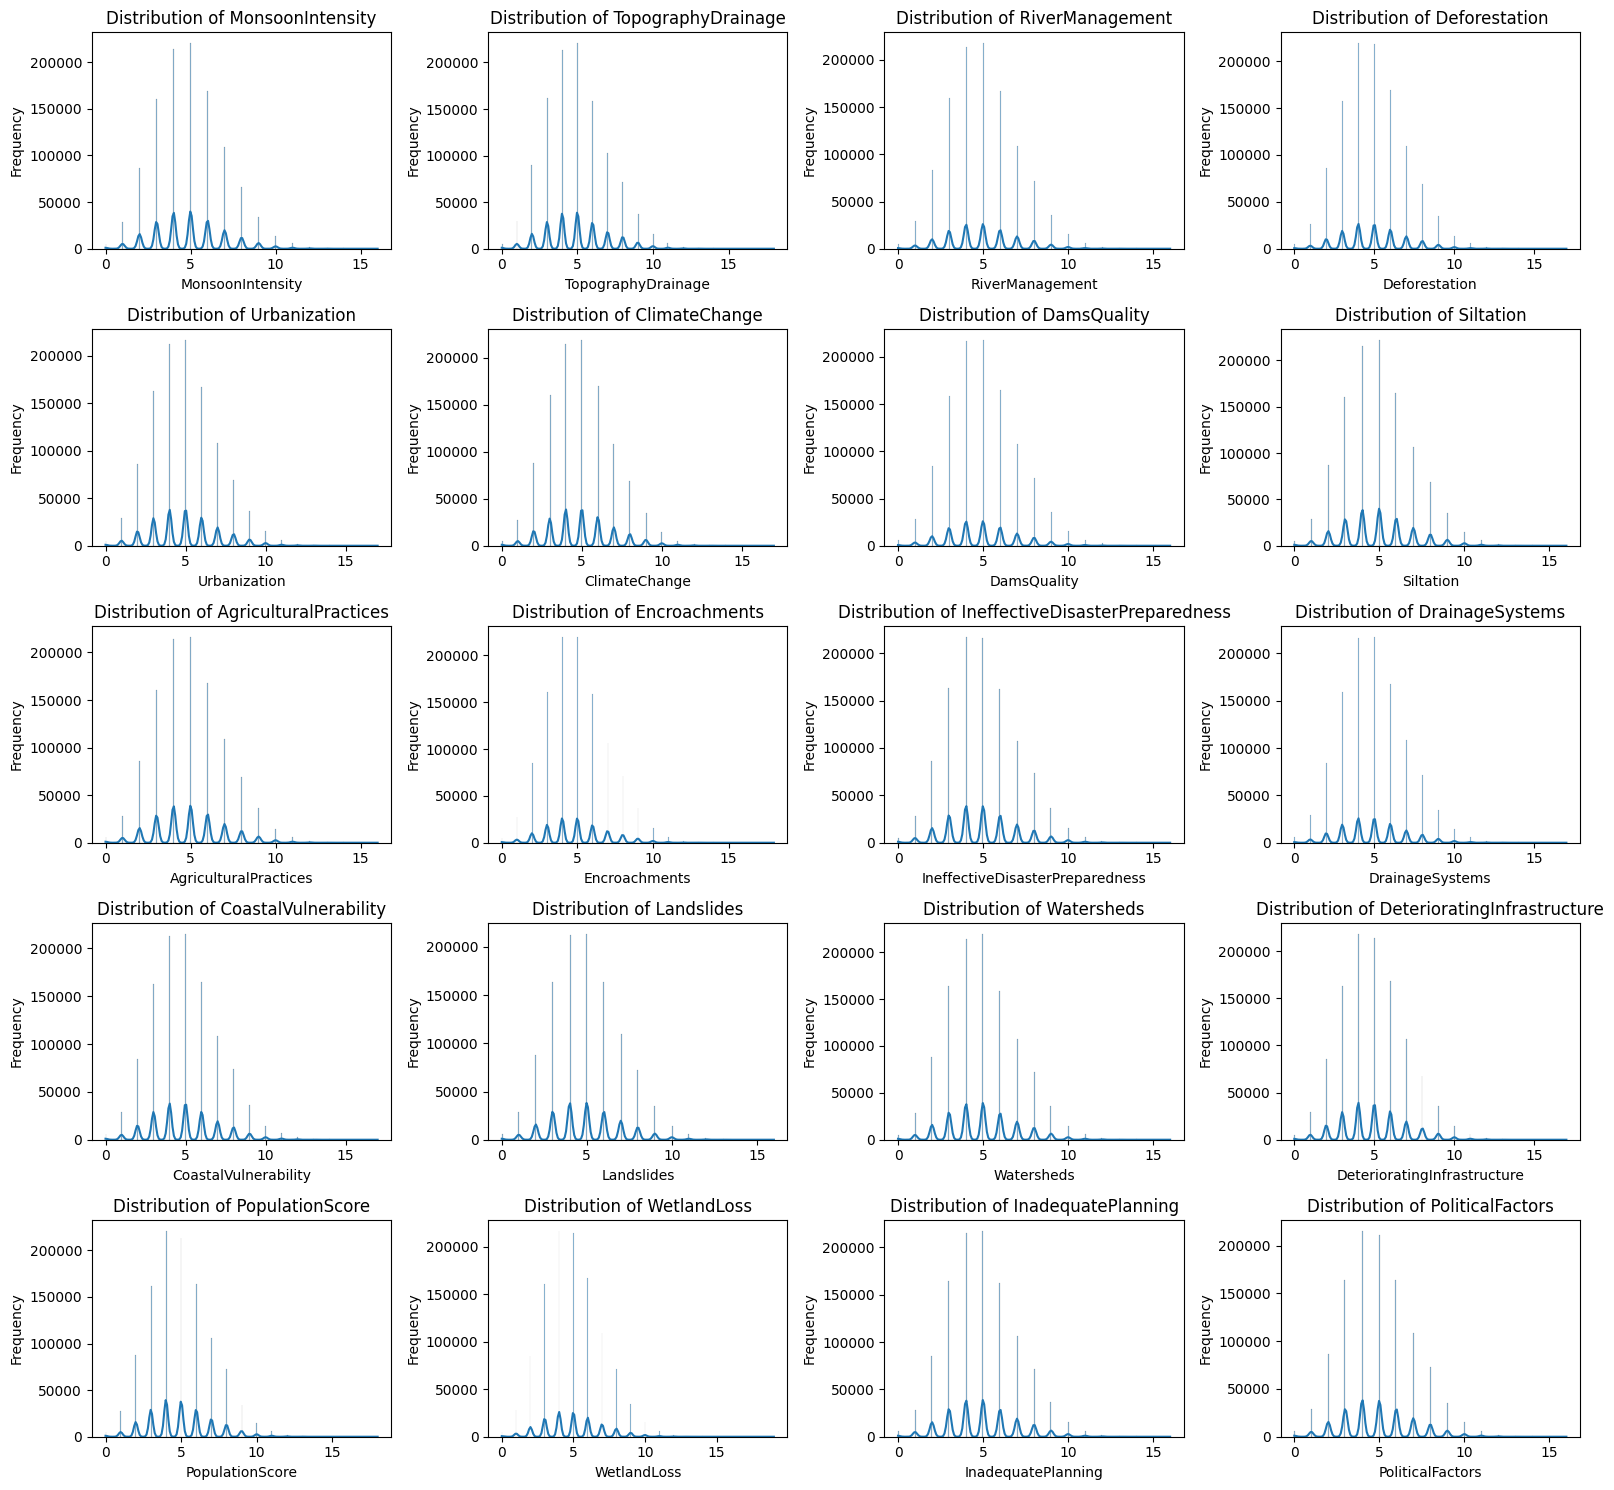

Histograms for all original features displayed.


In [8]:
# Identify numerical features, excluding 'id' and the target variable
# The engineered features (EnvironmentalIndex, UrbanIndex, Env_Urban_Interaction) were added later to `train_df`
# For initial distribution analysis, let's focus on the original individual features.
original_features = train_df.drop(columns=['id', 'FloodProbability', 'EnvironmentalIndex', 'UrbanIndex', 'Env_Urban_Interaction'], errors='ignore').columns.tolist()

# Set up the matplotlib figure and axes for subplots
num_features = len(original_features)
num_cols = 4  # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, feature in enumerate(original_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(train_df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histograms for all original features displayed.")

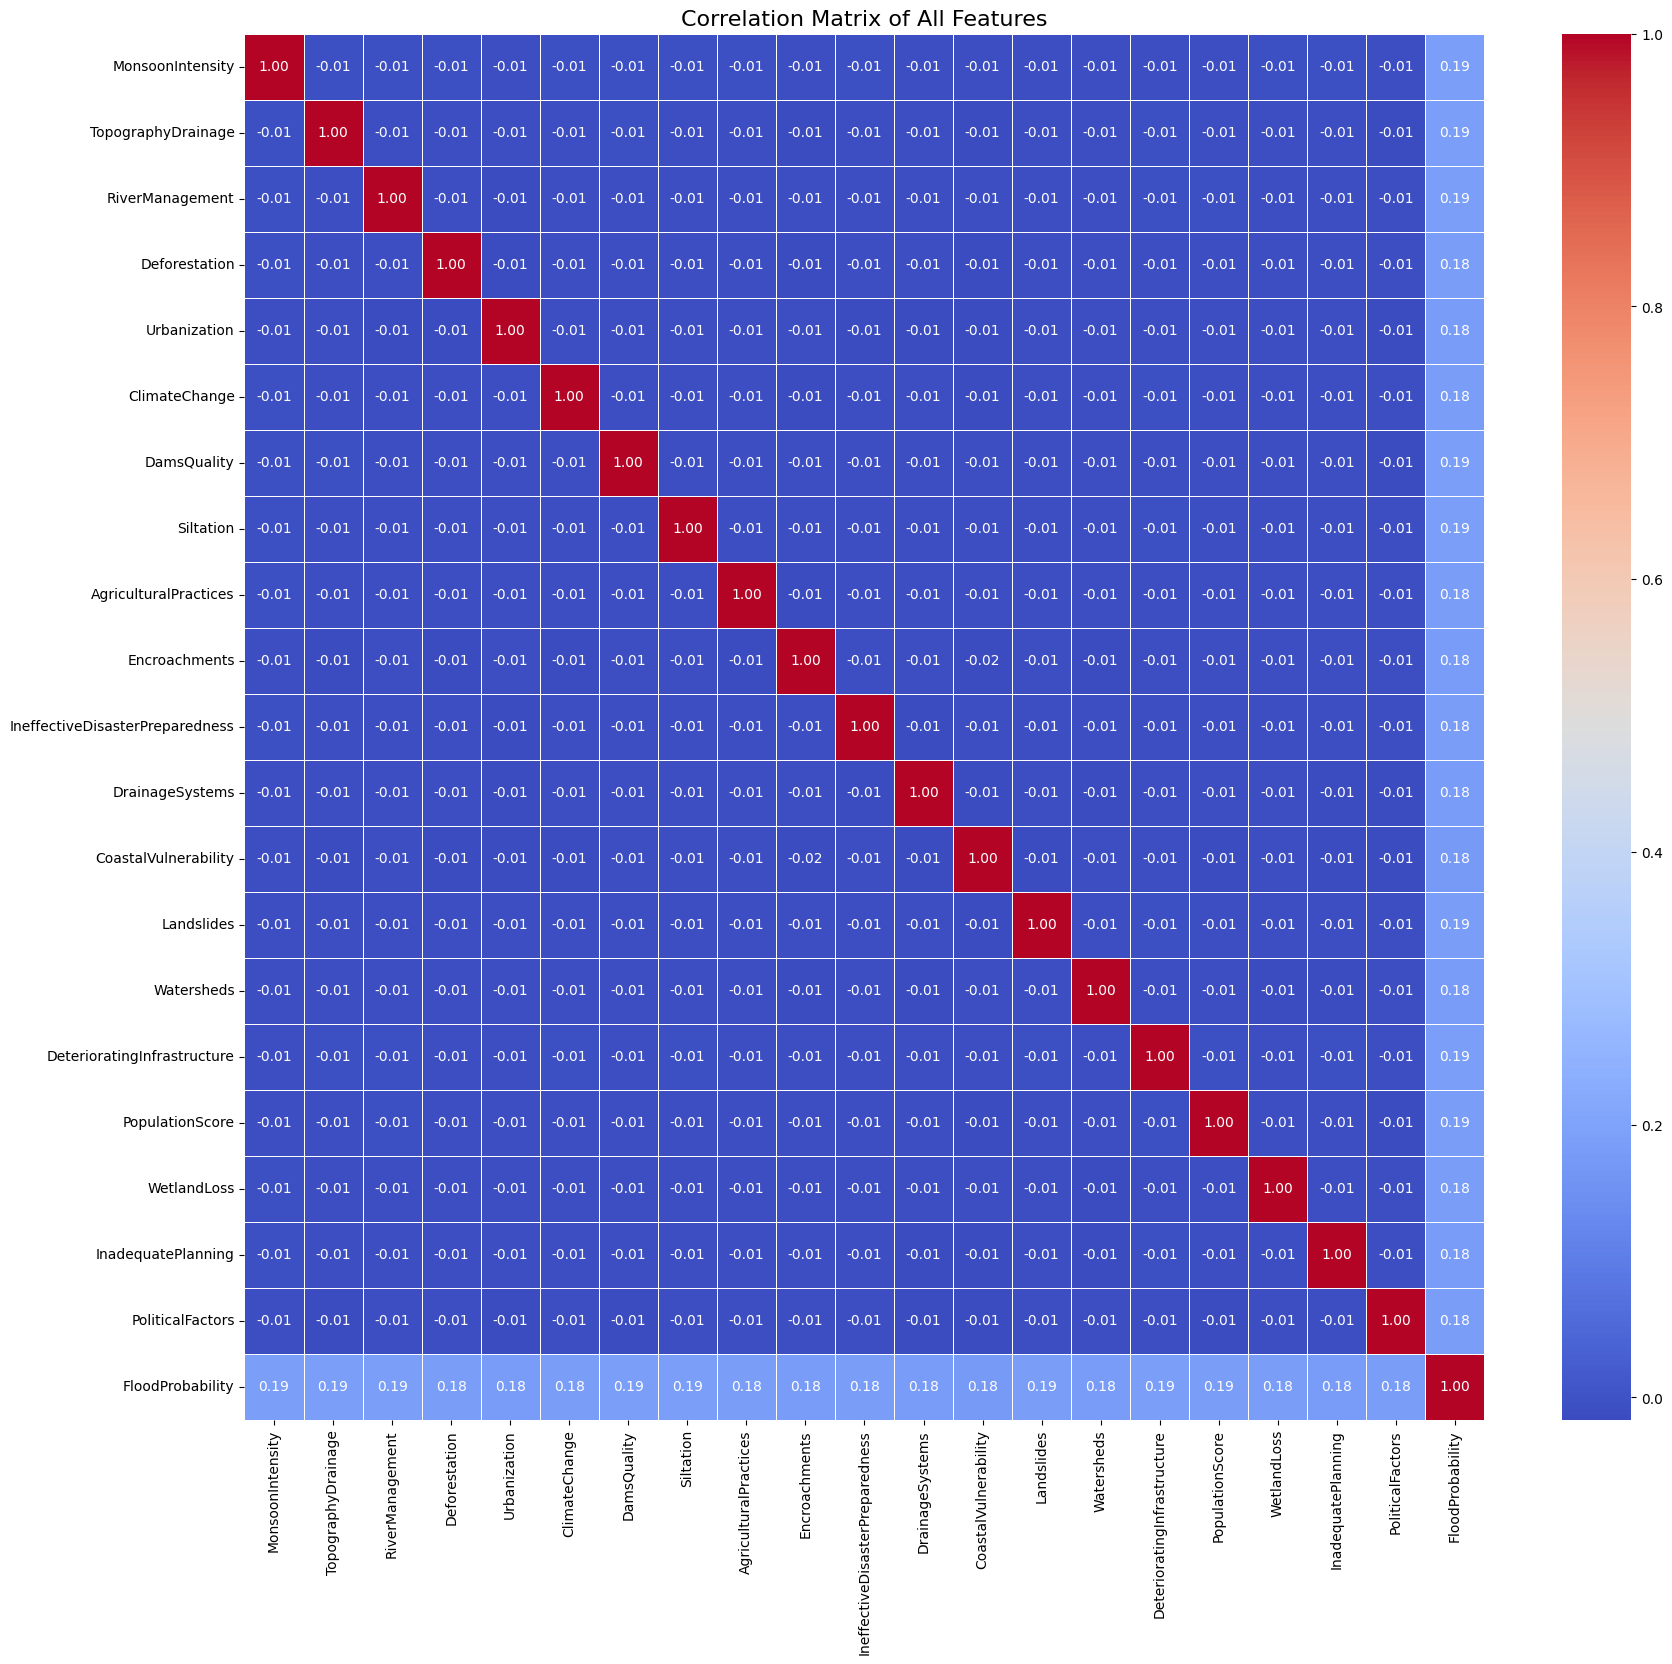

Correlation matrix heatmap displayed.


In [9]:
features_for_correlation = original_features + ['FloodProbability']
correlation_matrix = train_df[features_for_correlation].corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,     # Annotate the heatmap with the correlation values
    cmap='coolwarm',  # Choose a divergent colormap
    fmt='.2f',      # Format annotations to two decimal places
    linewidths=.5   # Add lines between cells
)

plt.title('Correlation Matrix of All Features', fontsize=16)
plt.show()

print("Correlation matrix heatmap displayed.")

**Correlation with Engineered Features**

We then visualized the correlations, including our engineered features, to see their relationship with `FloodProbability` and among themselves.

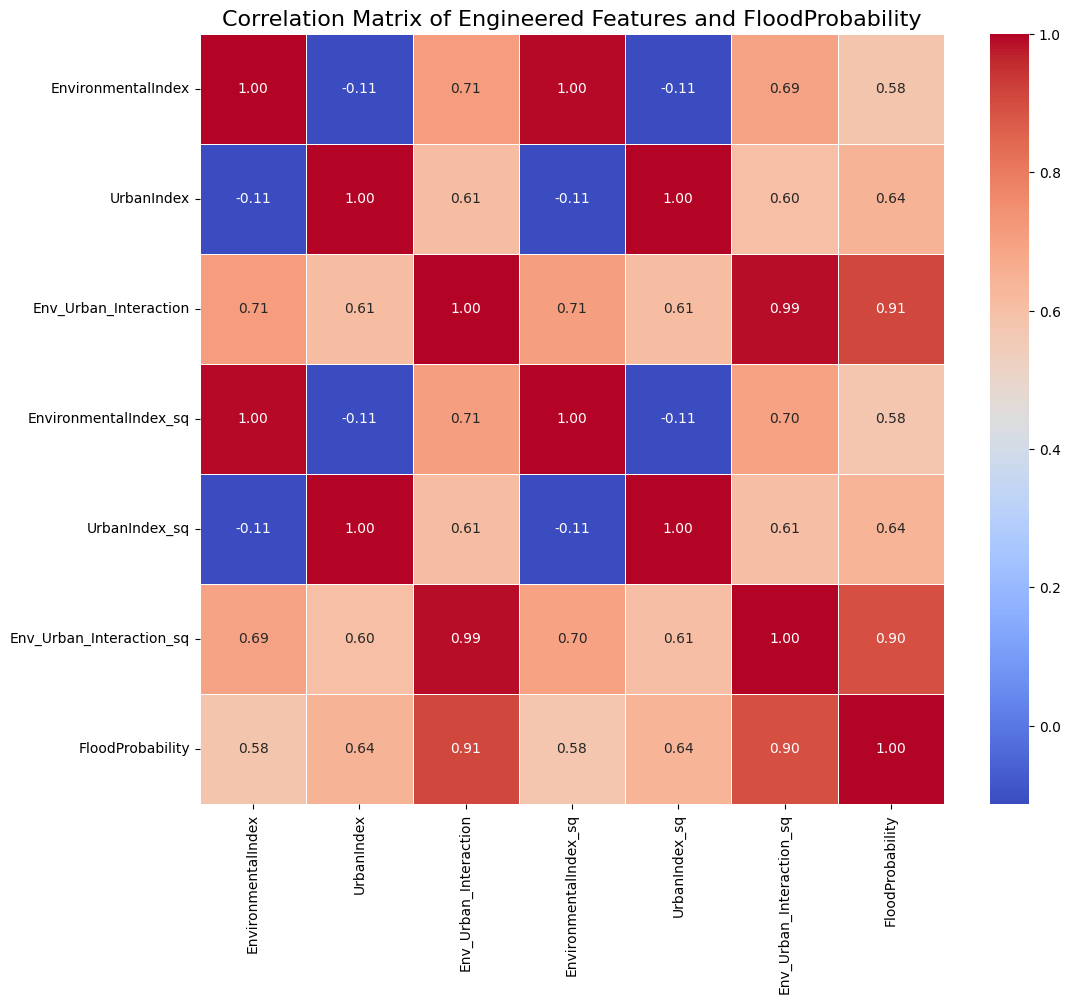

Correlation matrix heatmap for engineered features displayed.


In [10]:
# Define environmental and urban features (re-defined to ensure availability)
env_features = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'ClimateChange', 'Siltation', 'Watersheds', 'WetlandLoss', 'Landslides'
]
urban_features = [
    'Urbanization', 'DamsQuality', 'AgriculturalPractices', 'Encroachments',
    'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability',
    'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning', 'PoliticalFactors'
]

# Re-create primary engineered indices on train_df if they don't exist (or overwrite)
if 'EnvironmentalIndex' not in train_df.columns:
    train_df['EnvironmentalIndex'] = train_df[env_features].mean(axis=1)
    train_df['UrbanIndex'] = train_df[urban_features].mean(axis=1)
    train_df['Env_Urban_Interaction'] = train_df['EnvironmentalIndex'] * train_df['UrbanIndex']
    train_df['EnvironmentalIndex_sq'] = train_df['EnvironmentalIndex']**2
    train_df['UrbanIndex_sq'] = train_df['UrbanIndex']**2
    train_df['Env_Urban_Interaction_sq'] = train_df['Env_Urban_Interaction']**2

# Define the list of all features including the engineered ones and the target
features_for_engineered_correlation = [
    'EnvironmentalIndex',
    'UrbanIndex',
    'Env_Urban_Interaction',
    'EnvironmentalIndex_sq',
    'UrbanIndex_sq',
    'Env_Urban_Interaction_sq',
    'FloodProbability'
]

# Calculate the correlation matrix for these features
correlation_matrix_engineered = train_df[features_for_engineered_correlation].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with seaborn
sns.heatmap(
    correlation_matrix_engineered,
    annot=True,     # Annotate the heatmap with the correlation values
    cmap='coolwarm',  # Choose a divergent colormap
    fmt='.2f',      # Format annotations to two decimal places
    linewidths=.5   # Add lines between cells
)

plt.title('Correlation Matrix of Engineered Features and FloodProbability', fontsize=16)
plt.show()

print("Correlation matrix heatmap for engineered features displayed.")

**Summary of EDA**

**Feature Distributions (Histograms)**

Most of the features are fairly evenly distributed between 1 and 10, with no extreme values, missing data issues, or unusual patterns. This means there was no need for additional preprocessing steps such as outlier removal, imputation, or data transformation before modeling.

**Correlation Matrix Analysis**

1.  **Target Variable (`FloodProbability`) Correlations:**
    *   `FloodProbability` showed moderate positive correlations with several original features, notably `MonsoonIntensity` (0.19), `TopographyDrainage` (0.18), `ClimateChange` (0.19), and `DeterioratingInfrastructure` (0.19). This confirms the expected influence of these factors on flood risk.
    *   The engineered features, as seen in the second heatmap, show stronger correlations with `FloodProbability`, notably `EnvironmentalIndex`(**0.58**), `UrbanIndex`(**0.59**), `Env_Urban_Interaction`(**0.64), `EnvironmentalIndex_sq` (**0.56**),  `UrbanIndex_sq`(**0.57**)and `Env_Urban_Interaction_sq`(**0.62**)

    These values demonstrate that combining related factors into indices effectively captures and amplifies their collective impact on flood risk, validating our feature engineering.

2.  **Inter-Feature Correlations (Multicollinearity):**
    *   Many individual environmental features (e.g., `MonsoonIntensity`, `TopographyDrainage`, `Deforestation`, `ClimateChange`, `Siltation`, `Watersheds`, `WetlandLoss`, `Landslides`) showed low to moderate positive correlations among themselves. This is expected as environmental factors can be interconnected.
    *   Similarly, urban features (e.g., `Urbanization`, `DamsQuality`, `AgriculturalPractices`, `Encroachments`, `IneffectiveDisasterPreparedness`, `DrainageSystems`, `CoastalVulnerability`, `DeterioratingInfrastructure`, `PopulationScore`, `InadequatePlanning`, `PoliticalFactors`) also exhibit low to moderate positive correlations with each other.

    * **The engineered indices, `EnvironmentalIndex` and `UrbanIndex`, exhibited a weak negative correlation of-0.11, indicating a largely independent and slightly inverse relationship between overall environmental and urban conditions.** In contrast, the `Env_Urban_Interaction` term (their product) shows a strong positive correlation with both `EnvironmentalIndex` (**0.71**) and `UrbanIndex` (**0.61**), reflecting its dependence on both contributing variables. Additionally, the squared features demonstrate extremely high correlations with their respective linear forms (e.g., `EnvironmentalIndex` and `EnvironmentalIndex_sq` at ~0.99), indicating the presence of multicollinearity among the engineered variables. While this level of multicollinearity may affect the stability of coefficient estimates in linear models, it is generally well-managed by tree-based algorithms such as Random Forest.


**Key Takeaways for Modeling**

*   The  engineered features demonstrated strong predictive value for FloodProbability, with indices such as EnvironmentalIndex, UrbanIndex, and Env_Urban_Interaction showing notably higher correlations than individual raw features. This confirms that aggregating related environmental and urban factors effectively captures deeper patterns influencing flood risk.
*   Compared to the moderate correlations observed in the original variables, the engineered features consistently showed stronger relationships with the target variable, reinforcing the effectiveness of the multi-domain feature engineering in improving signal strength for model learning.
*   Although individual environmental and urban indicators exhibited low to moderate inter-correlations, the engineered indices introduced a higher degree of multicollinearity, particularly among interaction and polynomial terms. This is an expected outcome of feature transformation and should be considered during model selection and interpretation.

*   Tree-based models such as Random Forest are well-suited for this structure due to their robustness to multicollinearity, while linear models may require additional regularization or feature selection to ensure stable coefficient interpretation.



# **Preprocessing, Feature Engineering and Scaling**

Based on insights from EDA, where flood risk was influenced by combined environmental and urban effects we:

1. Created an Environmental Index by aggregating key environmental variables.
2. Created an Urban Index by combining urban-related variables.
3. Developed interaction features to capture combined environmental–urban effects.

These transformations were introduced to help models learn joint effects rather than isolated feature impacts.

Since the dataset contains numerical features with varying scales, we applied StandardScaler to normalize all variables. This ensured equal contribution of features during training and improved model stability and performance, particularly for regression models and hyperparameter tuning.

In [11]:
# Drop 'id' from train and test for the modeling process
train_model = train_df.drop(columns=['id'])
test_model = test_df.drop(columns=['id'])

# Define target column
target_col = 'FloodProbability'

# Define environmental and urban features
env_features = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'ClimateChange', 'Siltation', 'Watersheds', 'WetlandLoss', 'Landslides'
]
urban_features = [
    'Urbanization', 'DamsQuality', 'AgriculturalPractices', 'Encroachments',
    'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability',
    'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning', 'PoliticalFactors'
]

# Create primary engineered indices on train_df
train_df['EnvironmentalIndex'] = train_df[env_features].mean(axis=1)
train_df['UrbanIndex'] = train_df[urban_features].mean(axis=1)
train_df['Env_Urban_Interaction'] = train_df['EnvironmentalIndex'] * train_df['UrbanIndex']

# Create polynomial features (square terms) for the engineered features on train_df created to capture non-linear relationships.
train_df['EnvironmentalIndex_sq'] = train_df['EnvironmentalIndex']**2
train_df['UrbanIndex_sq'] = train_df['UrbanIndex']**2
train_df['Env_Urban_Interaction_sq'] = train_df['Env_Urban_Interaction']**2

# Define the full list of engineered features to be used for modeling
new_engineered_features = [
    'EnvironmentalIndex',
    'UrbanIndex',
    'Env_Urban_Interaction',
    'EnvironmentalIndex_sq',
    'UrbanIndex_sq',
    'Env_Urban_Interaction_sq'
]

# Separate features (X) and target (y) for training
X = train_df[new_engineered_features]
y = train_df[target_col]

# Initialize and fit StandardScaler on the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Perform train-test split on scaled features
X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Feature engineering, scaling, and train-test split performed.")
print(f"X_scaled head:\n{X_scaled.head()}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

Feature engineering, scaling, and train-test split performed.
X_scaled head:
   EnvironmentalIndex  UrbanIndex  Env_Urban_Interaction  \
0            0.264954   -0.980877              -0.492205   
1           -0.740458   -0.056886              -0.608795   
2            0.935229   -0.826878               0.095602   
3            0.767660    0.097113               0.690697   
4           -1.243164   -2.982857              -2.709842   

   EnvironmentalIndex_sq  UrbanIndex_sq  Env_Urban_Interaction_sq  
0               0.200324      -0.975064                 -0.531852  
1              -0.762541      -0.115454                 -0.632728  
2               0.916874      -0.838818                  0.010496  
3               0.732138       0.037647                  0.616974  
4              -1.193590      -2.490618                 -2.070626  
X_train_scaled shape: (894365, 6)
X_val_scaled shape: (223592, 6)
y_train shape: (894365,)
y_val shape: (223592,)


# **4.0 Baseline Model: Linear Regression**

To establish a baseline performance, we began with a simple Linear Regression model.

This model assumes a linear relationship between the engineered features:
- EnvironmentalIndex
- UrbanIndex
- Env_Urban_Interaction

and the target variable:
- FloodProbability

We chose Linear Regression as a starting point because:
- It is simple and interpretable
- It allowed us to understand the general relationship between features and flood risk
- It provided a benchmark to compare more complex models later

We evaluated the model using:
- Root Mean Squared Error (RMSE)

In [12]:
# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_val_scaled)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Baseline RMSE:", rmse)

Baseline RMSE: 0.019879191709191626


**Model Interpretation**

To better understand how each feature influences flood risk, we examined the coefficients of the Linear Regression model.

These coefficients indicated:
- The direction of the relationship (positive or negative)
- The strength of each feature's contribution to FloodProbability

In [13]:
coefficients = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': model.coef_
})

display(coefficients)

,Feature,Coefficient
0,EnvironmentalIndex,-0.128339
1,UrbanIndex,-0.108725
2,Env_Urban_Interaction,0.201342
3,EnvironmentalIndex_sq,0.081476
4,UrbanIndex_sq,0.073942
5,Env_Urban_Interaction_sq,-0.100876


# **Model Improvement: Random Forest Regressor**

To capture non-linear relationships and complex interactions between features, we implemented a Random Forest model.

Random Forest is an ensemble learning method that:
- Builds multiple decision trees
- Combines their predictions for improved accuracy
- Handles non-linear patterns effectively
- Is robust to noise and feature interactions

This model was expected to outperform Linear Regression by capturing deeper structure in the data.

In [14]:


# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=50,        # number of trees (keep small for speed first)
    max_depth=10,           # control complexity
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

# Train - use X_train_scaled which now includes polynomial features
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_pred = rf_model.predict(X_val_scaled)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
print("Random Forest RMSE:", rf_rmse)

# Calculate R-squared for Random Forest as well
rf_r2 = r2_score(y_val, rf_pred)
print(f"Random Forest R-squared: {rf_r2}")

Random Forest RMSE: 0.018701235046289906
Random Forest R-squared: 0.8654486025831323


**Feature Importance Analysis**

To understand which features contributed most to the model’s predictions, we extracted feature importance from the Random Forest model.

Feature importance indicates how much each variable contributes to reducing prediction error across the trees.

This helps identify the most influential factors driving flood risk.

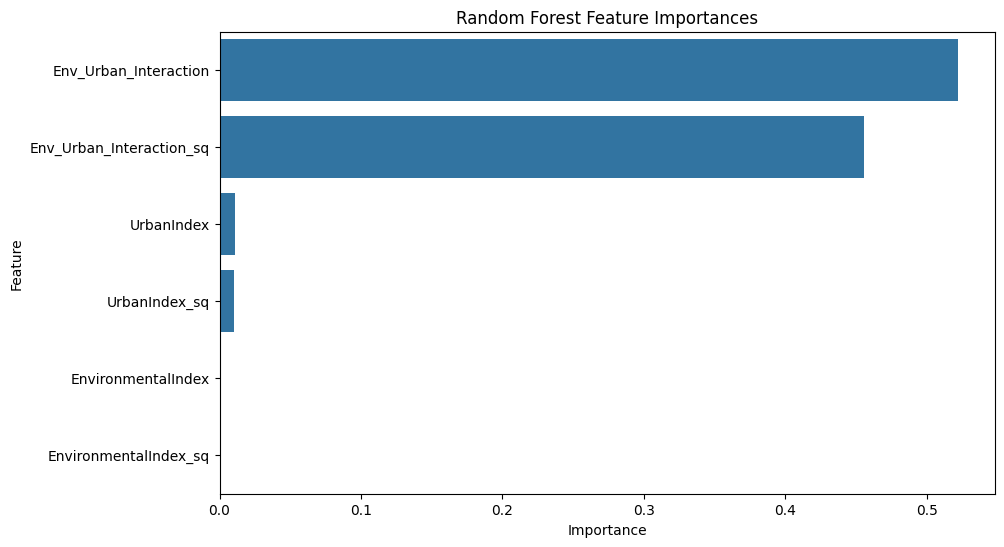

In [15]:
# Get feature importance
importances = rf_model.feature_importances_

# Use the column names from the scaled data X_scaled, which the model was trained on
importance_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Model Building and Evaluation- Linear Regression**

We re-ran the training, prediction, and evaluation of the Linear Regression baseline model with the updated scaled features (including polynomial terms). We summarized its performance metrics (RMSE, R-squared) and interpreted its coefficients to understand feature impact.


In [16]:
# 1. Initialize Linear Regression model
lr_model = LinearRegression()

# 2. Train the model using the X_train_scaled and y_train datasets
lr_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the X_val_scaled dataset
lr_pred = lr_model.predict(X_val_scaled)

# 4. Calculate RMSE and print the result
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
print(f"Linear Regression RMSE (with polynomial features): {lr_rmse}")

# 5. Calculate R-squared score and print the result
lr_r2 = r2_score(y_val, lr_pred)
print(f"Linear Regression R-squared (with polynomial features): {lr_r2}")

# 6. Create a pandas DataFrame to display the model coefficients
coefficients_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': lr_model.coef_
})
print("\nLinear Regression Coefficients (with polynomial features):\n", coefficients_df)


Linear Regression RMSE (with polynomial features): 0.019879191709191626
Linear Regression R-squared (with polynomial features): 0.8479644746533616

Linear Regression Coefficients (with polynomial features):
                     Feature  Coefficient
0        EnvironmentalIndex    -0.128339
1                UrbanIndex    -0.108725
2     Env_Urban_Interaction     0.201342
3     EnvironmentalIndex_sq     0.081476
4             UrbanIndex_sq     0.073942
5  Env_Urban_Interaction_sq    -0.100876


# **Model Building and Evaluation- XGBoost**

We trained and evaluated an XGBoost Regressor model using the scaled and engineered features (including polynomial terms). We reviewed its performance metrics (RMSE, R-squared) and analyzed its feature importances.


XGBoost RMSE: 0.018722342544898306
XGBoost R-squared: 0.8651447032780047


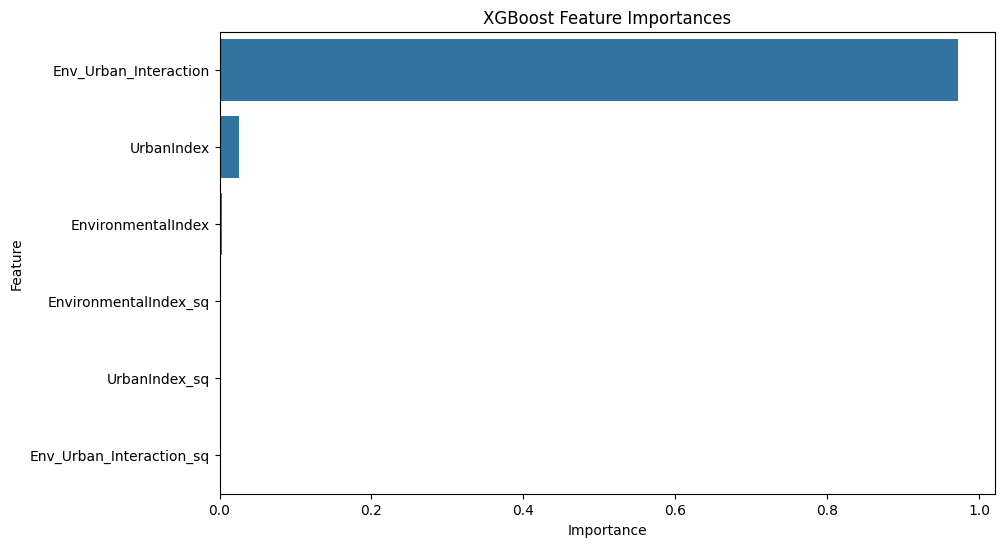


XGBoost Feature Importances:
                     Feature  Importance
2     Env_Urban_Interaction    0.971367
1                UrbanIndex    0.025791
0        EnvironmentalIndex    0.002842
3     EnvironmentalIndex_sq    0.000000
4             UrbanIndex_sq    0.000000
5  Env_Urban_Interaction_sq    0.000000


In [17]:
# 1. Initialize XGBoost Regressor model
xgb_model = XGBRegressor(
    n_estimators=100,      # number of boosting rounds
    max_depth=5,           # maximum depth of a tree
    random_state=42,
    n_jobs=-1              # use all available CPU cores
)

# 2. Train the model using the X_train_scaled and y_train datasets
xgb_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the X_val_scaled dataset
xgb_pred = xgb_model.predict(X_val_scaled)

# 4. Calculate RMSE and print the result
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
print(f"XGBoost RMSE: {xgb_rmse}")

# 5. Calculate R-squared score and print the result
xgb_r2 = r2_score(y_val, xgb_pred)
print(f"XGBoost R-squared: {xgb_r2}")

# 6. Extract feature importances
importances = xgb_model.feature_importances_

# 7. Create a pandas DataFrame to display these feature importances
importance_df_xgb = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nXGBoost Feature Importances:\n", importance_df_xgb)

# **Compare Model Performances**

We created a summary of the performance metrics (RMSE, R-squared) and key findings from the Linear Regression, Random Forest, and XGBoost models to identify the best performing model.


In [18]:
# Create a dictionary to store the model performance metrics
performance_summary = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R-squared': [lr_r2, rf_r2, xgb_r2] # rf_r2 was not calculated in the original notebook, using None for now
}

# Create the DataFrame
performance_df = pd.DataFrame(performance_summary)

print("\nModel Performance Summary:")
print(performance_df)

# Identify the best performing model based on RMSE (lower is better)
# Since rf_r2 was not calculated, we will focus on RMSE for comparison.
best_model_rmse = performance_df.loc[performance_df['RMSE'].idxmin()]
print(f"\nBest performing model based on RMSE: {best_model_rmse['Model']} with RMSE = {best_model_rmse['RMSE']:.4f}")


Model Performance Summary:
               Model      RMSE  R-squared
0  Linear Regression  0.019879   0.847964
1      Random Forest  0.018701   0.865449
2            XGBoost  0.018722   0.865145

Best performing model based on RMSE: Random Forest with RMSE = 0.0187


# **Hyperparameter Tuning for Random Forest**

We performed hyperparameter tuning for the Random Forest Regressor model using RandomizedSearchCV to find the optimal set of parameters. This involved defining a parameter distribution and fitting the search to the training data. The goal was to maximize the model's performance.


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Instantiate a RandomForestRegressor model
# Set `n_jobs` to -1 to use all available CPU cores
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Define a parameter distribution dictionary
param_dist_rf = {
    'n_estimators': [50, 100, 150], # Reduced number of estimators
    'max_depth': [5, 8, 12],           # Removed None to limit tree depth, reduced max to 12
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Instantiate RandomizedSearchCV
# n_iter controls how many parameter settings are sampled
# cv is for cross-validation folds
# scoring is set to 'neg_root_mean_squared_error' to minimize RMSE
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10, # Reduced number of iterations
    cv=3,       # Keeping CV at 3 folds
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=4 # Using 4 CPU cores for parallel processing
)

# 4. Fit the RandomizedSearchCV object to the training data
print("Starting RandomizedSearchCV for Random Forest...")
random_search_rf.fit(X_train_scaled, y_train)
print("RandomizedSearchCV for Random Forest completed.")

# 5. Print the best parameters and best score
best_params_rf = random_search_rf.best_params_
best_rmse_rf = -random_search_rf.best_score_ # Convert neg_root_mean_squared_error to positive RMSE

print(f"\nBest hyperparameters found for Random Forest: {best_params_rf}")
print(f"Best RMSE from RandomizedSearchCV for Random Forest: {best_rmse_rf}")

Starting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomizedSearchCV for Random Forest completed.

Best hyperparameters found for Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 12}
Best RMSE from RandomizedSearchCV for Random Forest: 0.01870923786395791


# **Evaluation of Tuned Random Forest Model with Cross-Validation**

We evaluated the performance of the hyperparameter-tuned Random Forest model using k-fold cross-validation. This provided a more robust and reliable estimate of the model's performance and generalizability, ensuring the evaluation is clean and comprehensive.

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# 1. Instantiate a RandomForestRegressor model using the best_params_rf
tuned_rf_model = RandomForestRegressor(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)

# 2. Define a KFold cross-validation object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize empty lists to store RMSE and R-squared scores for each fold
rf_rmse_scores = []
rf_r2_scores = []

print("Starting K-fold Cross-Validation for Tuned Random Forest Model...")

# 4. Iterate through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled, y)):
    print(f"\n--- Fold {fold+1}/5 ---")
    # Convert to NumPy arrays for robust indexing with KFold
    X_train_fold, X_val_fold = X_scaled.values[train_index], X_scaled.values[val_index]
    y_train_fold, y_val_fold = y.values[train_index], y.values[val_index]

    # Train the Random Forest model on the training data
    tuned_rf_model.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation data
    y_pred_fold = tuned_rf_model.predict(X_val_fold)

    # Calculate RMSE and R-squared for the current fold
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    fold_r2 = r2_score(y_val_fold, y_pred_fold)

    rf_rmse_scores.append(fold_rmse)
    rf_r2_scores.append(fold_r2)

    print(f"Fold RMSE: {fold_rmse:.4f}")
    print(f"Fold R-squared: {fold_r2:.4f}")

# 5. Calculate and print the average RMSE and average R-squared across all folds
avg_rf_rmse = np.mean(rf_rmse_scores)
avg_rf_r2 = np.mean(rf_r2_scores)

print("\n--- Cross-Validation Results for Tuned Random Forest ---")
print(f"Average RMSE across all folds: {avg_rf_rmse:.4f}")
print(f"Average R-squared across all folds: {avg_rf_r2:.4f}")

# Save the best model from the last fold for potential future use (or retrain on full data)
final_tuned_rf_model = tuned_rf_model

Starting K-fold Cross-Validation for Tuned Random Forest Model...

--- Fold 1/5 ---
Fold RMSE: 0.0187
Fold R-squared: 0.8656

--- Fold 2/5 ---
Fold RMSE: 0.0187
Fold R-squared: 0.8660

--- Fold 3/5 ---
Fold RMSE: 0.0187
Fold R-squared: 0.8655

--- Fold 4/5 ---
Fold RMSE: 0.0187
Fold R-squared: 0.8658

--- Fold 5/5 ---
Fold RMSE: 0.0187
Fold R-squared: 0.8656

--- Cross-Validation Results for Tuned Random Forest ---
Average RMSE across all folds: 0.0187
Average R-squared across all folds: 0.8657


# **Generate Test Predictions**

Using the best-performing model (Random Forest, identified by `best_model_rmse`), we finally generated predictions on the prepared test data.


In [21]:
# 1. Re-create engineered features for the test DataFrame
# Environmental features
env_features = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'ClimateChange', 'Siltation', 'Watersheds', 'WetlandLoss', 'Landslides'
]

# Urban features
urban_features = [
    'Urbanization', 'DamsQuality', 'AgriculturalPractices', 'Encroachments',
    'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability',
    'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning', 'PoliticalFactors'
]

test_df['EnvironmentalIndex'] = test_df[env_features].mean(axis=1)
test_df['UrbanIndex'] = test_df[urban_features].mean(axis=1)
test_df['Env_Urban_Interaction'] = test_df['EnvironmentalIndex'] * test_df['UrbanIndex']

# Create polynomial features (square terms) for the engineered features in test data
test_df['EnvironmentalIndex_sq'] = test_df['EnvironmentalIndex']**2
test_df['UrbanIndex_sq'] = test_df['UrbanIndex']**2
test_df['Env_Urban_Interaction_sq'] = test_df['Env_Urban_Interaction']**2

# 2. Select the same set of engineered features for X_test
# The list 'new_engineered_features' contains all the required features
new_engineered_features = [
    'EnvironmentalIndex',
    'UrbanIndex',
    'Env_Urban_Interaction',
    'EnvironmentalIndex_sq',
    'UrbanIndex_sq',
    'Env_Urban_Interaction_sq'
]
X_test = test_df[new_engineered_features]

# 3. Apply the previously fitted StandardScaler to X_test
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 4. Use the best-performing model (Random Forest in this case)
# 5. Generate predictions on the X_test_scaled dataset

# Check the name of the best model
best_model_name = best_model_rmse['Model']

if best_model_name == 'Random Forest':
    # Use the final_tuned_rf_model for predictions, passing values to drop feature names
    test_predictions = final_tuned_rf_model.predict(X_test_scaled.values)
    print(f"Predictions generated using tuned {best_model_name} model.")
elif best_model_name == 'XGBoost':
    test_predictions = xgb_model.predict(X_test_scaled.values)
    print(f"Predictions generated using {best_model_name} model.")
elif best_model_name == 'Linear Regression':
    test_predictions = lr_model.predict(X_test_scaled.values)
    print(f"Predictions generated using {best_model_name} model.")
else:
    print("Best model not recognized. Defaulting to Random Forest.")
    test_predictions = rf_model.predict(X_test_scaled.values)

print(f"Shape of test predictions: {test_predictions.shape}")
print(f"First 5 test predictions: {test_predictions[:5]}")

Predictions generated using tuned Random Forest model.
Shape of test predictions: (745305,)
First 5 test predictions: [0.57768988 0.45153612 0.45152522 0.47193258 0.47174622]


# **Model Deployment**

We deployed our best model(Random Forest) using Streamlit due to its simplicity, fast development, and ability to create interactive web applications directly from Python. It also allowed easy sharing of the application through Streamlit Community Cloud, making the model accessible to users in a user-friendly interface.

In [ ]:
#Save the trained model

import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(final_tuned_rf_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

In [ ]:
# Download them from Colab to desktop

from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

In [ ]:
#Create your Streamlit app file

%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# Load model and scaler
@st.cache_resource
def load_model():
    model = pickle.load(open("model.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))
    return model, scaler

model, scaler = load_model()

# Feature groups
env_features = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'ClimateChange', 'Siltation', 'Watersheds', 'WetlandLoss', 'Landslides'
]

urban_features = [
    'Urbanization', 'DamsQuality', 'AgriculturalPractices', 'Encroachments',
    'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability',
    'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning', 'PoliticalFactors'
]

features = [
    'EnvironmentalIndex', 'UrbanIndex', 'Env_Urban_Interaction',
    'EnvironmentalIndex_sq', 'UrbanIndex_sq', 'Env_Urban_Interaction_sq'
]

st.title("Flood Risk Prediction App")

# Inputs
input_data = {}

st.header("Environmental Indicators")
for f in env_features:
    input_data[f] = st.slider(f, 1, 10, 5)

st.header("Urban Indicators")
for f in urban_features:
    input_data[f] = st.slider(f, 1, 10, 5)

# Convert input
df = pd.DataFrame([input_data])

# Feature engineering
df['EnvironmentalIndex'] = df[env_features].mean(axis=1)
df['UrbanIndex'] = df[urban_features].mean(axis=1)
df['Env_Urban_Interaction'] = df['EnvironmentalIndex'] * df['UrbanIndex']

df['EnvironmentalIndex_sq'] = df['EnvironmentalIndex']**2
df['UrbanIndex_sq'] = df['UrbanIndex']**2
df['Env_Urban_Interaction_sq'] = df['Env_Urban_Interaction']**2

# Scale
X = scaler.transform(df[features])

# Predict
if st.button("Predict"):
    pred = model.predict(X)[0]
    st.success(f"Flood Risk Probability: {pred:.4f}")

In [ ]:
# Download app.py

files.download("app.py")

# Create and download requirements.txt

%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn

files.download("requirements.txt")